In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
#pip install plotly hyperiax jaxdifferentialgeometry

# DICAROS pipeline

This document is the detailed versions of the dicros pipeline for mean shape estimation and ancestral shape reconstruction.

**Step 0: Data preparation**
Load in data, check for missing values and transform to the correct format.


**Step 1: Mean shape estimation**
Estimate the mean shape pr species.
Note this can either be done by the common mean or frechet mean. 


**Step 2: Ancestral shape reconstruction**
Estimate the ancestral shape for inner nodes






In [4]:
# Import packages 
import os

import pandas as pd
import numpy as np


# Step 1
from help_functions.align_functions import *
from help_functions.mean_estimator import *
from help_functions.mean_estimator_Frechet import *
from help_functions.shape_reconstruction import * 


# Step 2

import hyperiax
import jax
from jax import numpy as jnp
from jax import vmap, lax

from hyperiax.tree.topology import read_topology
from hyperiax.tree import HypTree

In [23]:

# Inputs to select from 

# Use idx landmarks for alignment 
idxs = [0, 29, 57] 
#idxs = None 

# dimensions of input data
d = 3


mean_shape_save = None 
output_dir = "output"
filename_mean = "male_dataset3.csv"

# Select mean estimator 
frechet = False 

# Load in data

This section is more user dependent, and the data should be loaded in the correct format. 

In [24]:
df = pd.read_csv('start_data/justLandmarks.csv')
print(np.shape(df))
print(df.head())
species_all= df['genus_species']
start_landmarks = df.iloc[:, 2:]



(1299, 467)
     Id                genus_species    lm1x   lm1y  lm1z    lm2x   lm2y  \
0   426  Allenopithecus_nigroviridis -40.539  2.961     0 -38.680  3.157   
1  2384  Allenopithecus_nigroviridis -37.557  2.557     0 -35.962  2.257   
2  2385  Allenopithecus_nigroviridis -36.932  3.300     0 -35.884  2.927   
3  2386  Allenopithecus_nigroviridis -34.474  4.777     0 -34.490  4.072   
4  2387  Allenopithecus_nigroviridis -34.676  3.883     0 -33.381  3.153   

    lm2z    lm3x   lm3y  ...  lm152z  lm153x  lm153y  lm153z  lm154x  lm154y  \
0  5.226 -35.323  2.555  ... -18.082   6.295 -26.927 -16.115   9.995 -13.435   
1  4.788 -32.905  2.204  ... -17.425   0.956 -26.890 -11.980  11.462 -14.615   
2  4.358 -32.296  3.226  ... -16.773  -1.633 -27.967 -11.882   8.605 -14.990   
3  4.158 -32.045  3.005  ... -16.939   0.129 -24.595  -7.555   9.247 -14.498   
4  4.038 -30.916  2.707  ... -17.399   0.489 -25.145  -9.825   9.846 -14.718   

   lm154z  lm155x  lm155y  lm155z  
0 -17.613  18.

# Make mean shape

In [29]:
if frechet: 
    start_landmarks = start_landmarks.iloc[:20, :]
    start_landmarks=start_landmarks.iloc[:,:31]
    species_all = species_all.iloc[:20]

    out_df = make_species_frechet_mean_common(start_landmarks,species_all,idxs,d)
    out_df = make_species_frechet_mean_common(start_landmarks,species_all,idxs,d)

        
    # For cpu testing
    #out_df= out_df.iloc[:,0:10]
    out_df= out_df.iloc[:,0:14] # Test in 3d 

else: 
    # Reduce the landmark set to the first 20 rows for testing
   # start_landmarks = start_landmarks.iloc[:20, :]
   # start_landmarks=start_landmarks.iloc[:,:15]
    #species_all = species_all.iloc[:20]
    idxs = [0, 29,70] 
    out_df1 = make_species_mean_common(start_landmarks,species_all,idxs,d)
    
    idxs = None
    out_df2 = make_species_mean_common(start_landmarks,species_all,idxs,d)





Three
landmarks_list (22, 465)
landmarks_nd (22, 155, 3)
Four


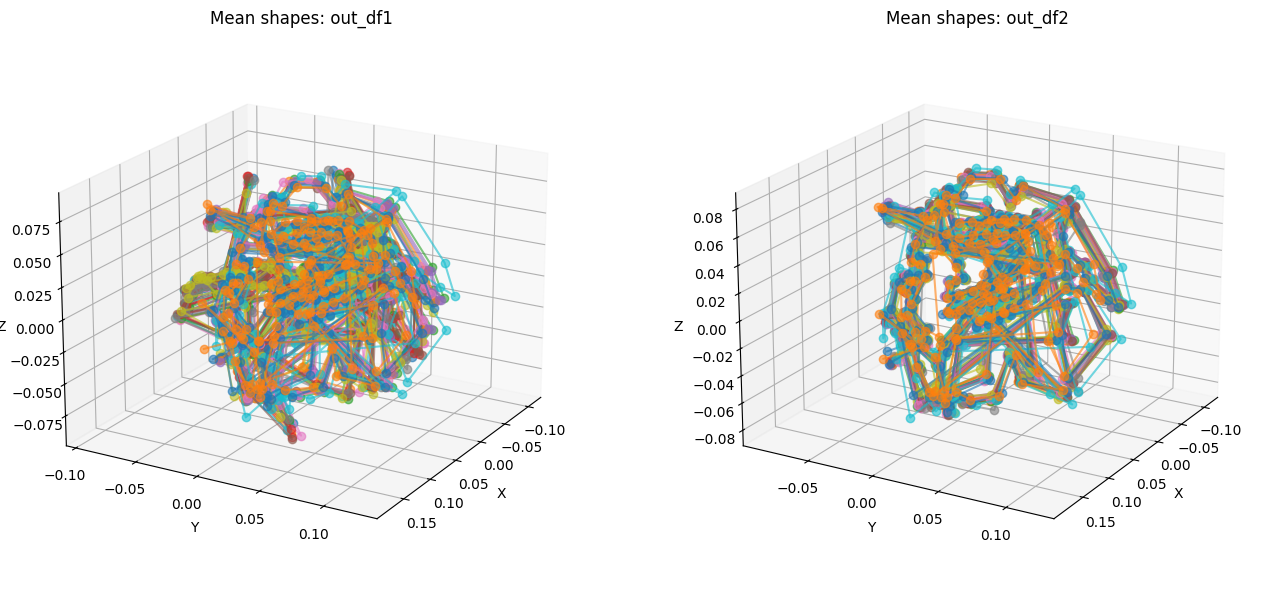

In [30]:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Plot mean shapes for each species in out_df1 and out_df2 side by side (3D)
# Assumes both out_df1 and out_df2 have: species, count, x1, y1, z1, ..., xn, yn, zn

fig = plt.figure(figsize=(14, 6))
axs = [
    fig.add_subplot(1, 2, 1, projection='3d'),
    fig.add_subplot(1, 2, 2, projection='3d')
]

for i, (out_df, ax, title) in enumerate(zip(
    [out_df1, out_df2],
    axs,
    ["Mean shapes: out_df1", "Mean shapes: out_df2"]
)):
    if out_df is not None:
        # figure out number of landmarks and 3d
        n_landmarks = (out_df.shape[1] - 2) // 3

        for _, row in out_df.iterrows():
            species = row[0]
            # get interleaved x, y, z
            xs = row[2 : 2 + 3 * n_landmarks : 3].values.astype(float)
            ys = row[3 : 2 + 3 * n_landmarks : 3].values.astype(float)
            zs = row[4 : 2 + 3 * n_landmarks : 3].values.astype(float)
            ax.plot(xs, ys, zs, marker='o', label=str(species), alpha=0.6)
        
        ax.set_title(title)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.view_init(elev=20, azim=30)
        #ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
        ax.grid(True)

plt.tight_layout()
plt.show()


## Populate inner nodes with a shapes

Using DICAROS 

Note this require the installation of Hyperiax and jaxgeoemetry 

In [ ]:


fline=open("./start_data/species_tree_male.txt").readline().rstrip()
# open(corrected_dataset+"/species_male_tree_rooted.txt").readline().rstrip()
tree = read_topology(fline,precompute_child_gathers=True)




In [ ]:
from help_functions.shape_reconstruction import * 


tree = tree_initialization(tree,out_df,d)

In [ ]:


# Detect if GPU is available; fallback to CPU if not
available_devices = jax.devices()
gpu_devices = [dev for dev in available_devices if dev.platform == "cuda"]

if gpu_devices:
    # Use the first GPU, or configurable by selector if needed
    selected_device = gpu_devices[0]
    print(f"Using device: {selected_device} (GPU)")
else:
    # Fallback to CPU if no GPU available
    cpu_devices = [dev for dev in available_devices if dev.platform == "cpu"]
    if not cpu_devices:
        raise RuntimeError("No CPU or GPU device found for JAX.")
    selected_device = cpu_devices[0]
    print(f"GPU not found, using device: {selected_device} (CPU)")


# Do reconstruction
# NOTE NOT GPU 

upmodel = UpLambda(up_fn=fuse_edgelength)
upmodelexe = OrderedExecutor(upmodel)
res = upmodelexe.up(tree) 


upmodel = UpLambda(up_fn=fuse_DICAROS)
upmodelexe = OrderedExecutor(upmodel)
res = upmodelexe.up(tree) 


# Save output 

In [ ]:
# Just to save, should be placed in a file 

from hyperiax.tree.topology import write_topology
# make output dir
os.makedirs("./reconstructed", exist_ok=True)

i = 0 
for node in tree.iter_topology_bfs():
    #print(node.name)
    if node.children!=[]:
        node.name = "xx_"+str(i)
        i+=1

# write topology there
tree_string_out = write_topology(tree)
# write to file
with open("./reconstructed/species_male_tree.txt", "w") as f:
    f.write(tree_string_out)


# reconstructed
node_names = [node.name for node in tree.iter_topology_bfs()]
# collect all recontstruct
reconstructed_shapes = tree.data["value"]


# Compare to edgelength to be sure
reconstructed_edgelengths = tree.data["edge_length"]


shapes = pd.DataFrame(reconstructed_shapes)
# add column to shapes, as first collumn node names
shapes.insert(0, 'node_names', node_names)

# add edges as second column
shapes.insert(1, 'edges', reconstructed_edgelengths)

# Export to csv
shapes.to_csv("./reconstructed/male_reconstructed_shapes.csv", index=False)


